## Project Overview

This project focuses on analyzing sales data to understand overall business performance using SQL and Python.  
The objective is to extract meaningful insights related to sales trends, category level performance, and the relationship between key business metrics.

SQL is used to store and aggregate the data efficiently, while Pandas is used for data processing and analysis.  
Matplotlib and Seaborn are used to visualize trends and patterns that help in better decision making.

The project demonstrates an end to end data analytics workflow starting from raw data to business insights.


## Data Source Description

The dataset used in this project is a sales dataset containing transactional level information.  
It includes details such as order date, product category, region, sales amount, profit, and quantity sold.

The data was initially available in CSV format and was then loaded into a SQLite database for SQL based analysis.  
This dataset represents a typical retail sales scenario and is suitable for understanding sales performance, profitability, and customer purchasing trends.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [19]:
import pandas as pd
df = pd.read_csv("superstore_big.csv")
df.head()


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,ORD-100001,2018-09-12,2018-09-17,Standard Class,CUST-1018,Rohan,Home Office,India,Chennai,...,846412,South,PROD-434,Technology,Machines,Machines - Premium Quality,753.08,3,0.20,-37.65
1,2,ORD-100002,2017-01-29,2017-02-04,Standard Class,CUST-1067,Rahul,Corporate,India,Delhi,...,910360,North,PROD-208,Office Supplies,Labels,Labels - Premium Quality,533.76,5,0.20,-26.69
2,3,ORD-100003,2017-08-16,2017-08-17,Standard Class,CUST-1031,Anaya,Corporate,India,Delhi,...,854792,North,PROD-308,Furniture,Chairs,Chairs - Premium Quality,1072.60,5,0.10,53.63
3,4,ORD-100004,2017-08-20,2017-08-26,Standard Class,CUST-1059,Virat,Home Office,India,Mumbai,...,213034,West,PROD-614,Furniture,Bookcases,Bookcases - Premium Quality,358.51,3,0.20,-17.93
4,5,ORD-100005,2017-04-02,2017-04-08,Same Day,CUST-1039,Meera,Home Office,India,Hyderabad,...,216605,South,PROD-100,Technology,Phones,Phones - Premium Quality,1805.84,4,0.05,180.58


In [3]:
connection = sqlite3.connect("superstore_big.db")
df.to_sql("sales", connection, if_exists="replace", index=False)


300

In [4]:
query = """
SELECT Category, SUM(Sales) AS TotalSales
FROM sales
GROUP BY Category
ORDER BY TotalSales DESC;
"""

result = pd.read_sql_query(query, connection)
result

,Category,TotalSales
0,Technology,121567.79
1,Furniture,94090.89
2,Office Supplies,85289.22


In [5]:
query = """
SELECT Region, SUM(Profit) AS TotalProfit
FROM sales
GROUP BY Region
ORDER BY TotalProfit DESC;
"""
pd.read_sql_query(query, connection)


,Region,TotalProfit
0,South,9898.28
1,West,4215.85
2,North,2429.47


In [6]:
query = """
SELECT Product_Name, SUM(Sales) AS TotalSales
FROM sales
GROUP BY Product_Name
ORDER BY TotalSales DESC
LIMIT 10;
"""
pd.read_sql_query(query, connection)


,Product_Name,TotalSales
0,Accessories - Premium Quality,43410.43
1,Chairs - Premium Quality,40090.46
2,Phones - Premium Quality,39239.35
3,Machines - Premium Quality,38918.01
4,Binders - Premium Quality,38610.16
5,Bookcases - Premium Quality,28966.01
6,Tables - Premium Quality,25034.42
7,Labels - Premium Quality,24998.37
8,Paper - Premium Quality,21680.69


In [7]:
query = """
SELECT Region, SUM(Profit) AS TotalProfit
FROM sales
GROUP BY Region
ORDER BY TotalProfit DESC;
"""
pd.read_sql_query(query, connection)


,Region,TotalProfit
0,South,9898.28
1,West,4215.85
2,North,2429.47


In [8]:
query = """
SELECT 
    strftime('%Y-%m', "Order_Date") AS Month,
    SUM(Sales) AS TotalSales
FROM sales
GROUP BY Month
ORDER BY Month;
"""
pd.read_sql_query(query, connection)


,Month,TotalSales
0,2017-01,4185.53
1,2017-02,13099.40
2,2017-03,8734.74
3,2017-04,8588.46
4,2017-05,8262.31
5,2017-06,2657.73
6,2017-07,9417.22
7,2017-08,10347.00
8,2017-09,12460.62
9,2017-10,9140.79


In [20]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [23]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

df.head()


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name
0,1,ORD-100001,2018-09-12,2018-09-17,Standard Class,CUST-1018,Rohan,Home Office,India,Chennai,...,Technology,Machines,Machines - Premium Quality,753.08,3,0.20,-37.65,2018,9,September
1,2,ORD-100002,2017-01-29,2017-02-04,Standard Class,CUST-1067,Rahul,Corporate,India,Delhi,...,Office Supplies,Labels,Labels - Premium Quality,533.76,5,0.20,-26.69,2017,1,January
2,3,ORD-100003,2017-08-16,2017-08-17,Standard Class,CUST-1031,Anaya,Corporate,India,Delhi,...,Furniture,Chairs,Chairs - Premium Quality,1072.60,5,0.10,53.63,2017,8,August
3,4,ORD-100004,2017-08-20,2017-08-26,Standard Class,CUST-1059,Virat,Home Office,India,Mumbai,...,Furniture,Bookcases,Bookcases - Premium Quality,358.51,3,0.20,-17.93,2017,8,August
4,5,ORD-100005,2017-04-02,2017-04-08,Same Day,CUST-1039,Meera,Home Office,India,Hyderabad,...,Technology,Phones,Phones - Premium Quality,1805.84,4,0.05,180.58,2017,4,April


In [24]:
monthly_trend = (
    df.groupby(['Year', 'Month_Name'])
      .agg({'Sales': 'sum', 'Profit': 'sum'})
      .reset_index()
)

monthly_trend.head()


,Year,Month_Name,Sales,Profit
0,2017,April,8588.46,767.50
1,2017,August,10347.00,806.67
2,2017,December,7884.23,651.76
3,2017,February,13099.40,839.59
4,2017,January,4185.53,288.62


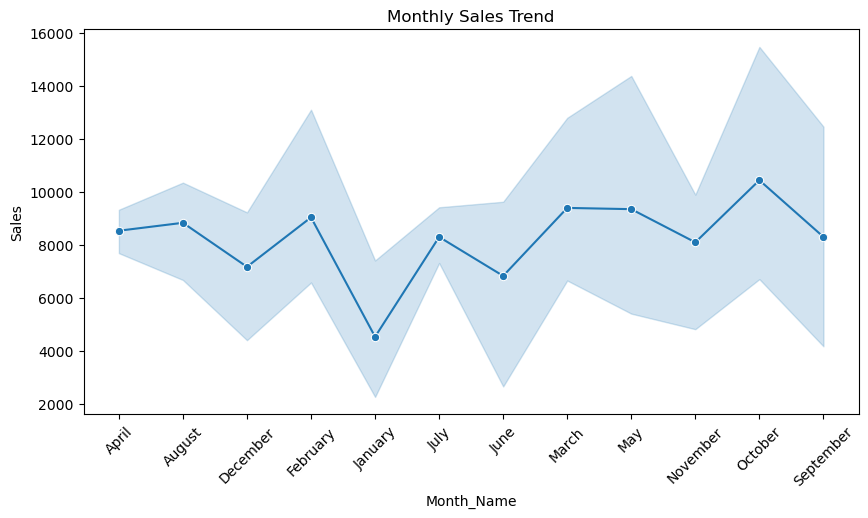

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_trend, x='Month_Name', y='Sales', marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

In [14]:
category_region = (
    df.groupby(['Category', 'Region'])
      .agg({
          'Sales': 'sum',
          'Profit': 'sum',
          'Quantity': 'sum'
      })
      .reset_index()
)

category_region.head()


,Category,Region,Sales,Profit,Quantity
0,Furniture,North,19422.82,871.64,66
1,Furniture,South,50741.90,3085.39,180
2,Furniture,West,23926.17,963.80,70
3,Office Supplies,North,15979.36,758.86,48
4,Office Supplies,South,40837.77,1483.79,128


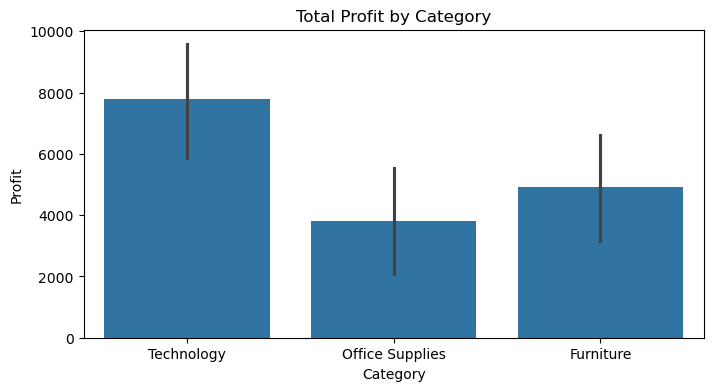

In [15]:
plt.figure(figsize =(8,4))
sns.barplot(data=df,x='Category',y='Profit',estimator=sum)
plt.title("Total Profit by Category")
plt.show()

In [16]:
top_products =(
    df.groupby('Product_Name')['Sales']
    .sum()
    .nlargest(10)
    .reset_index()
)
top_products.head()

,Product_Name,Sales
0,Accessories - Premium Quality,43410.43
1,Chairs - Premium Quality,40090.46
2,Phones - Premium Quality,39239.35
3,Machines - Premium Quality,38918.01
4,Binders - Premium Quality,38610.16


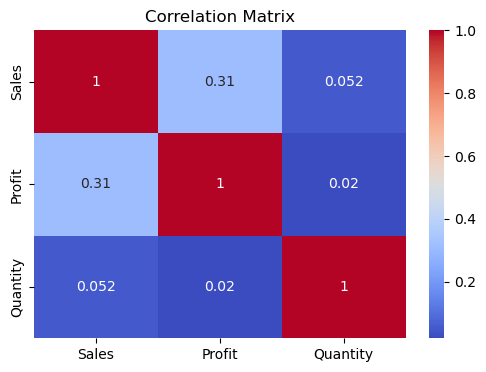

In [17]:
corr = df[['Sales', 'Profit', 'Quantity']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

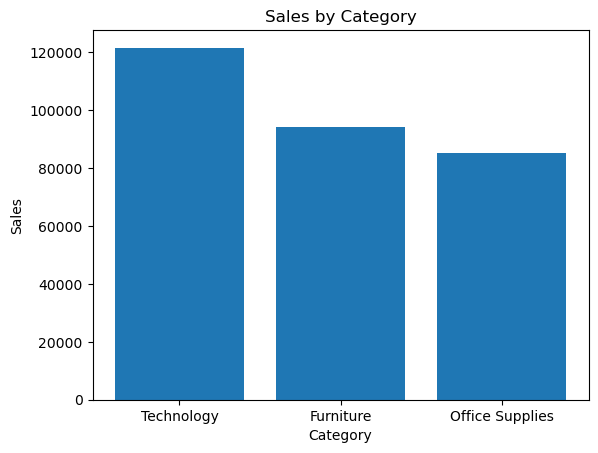

In [18]:
plt.bar(result['Category'], result['TotalSales'])
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Sales by Category")
plt.show()


## Key Business Insights

Insights from SQL Analysis  
SQL queries were used to aggregate sales and profit data efficiently at category and regional levels.  
The analysis shows that sales and profit are not evenly distributed across categories, with certain categories contributing more to overall business performance.  
Category level aggregation helped in understanding which product groups are more profitable and require more business focus.

Insights from Pandas Analysis and Visualization  
The monthly sales line plot shows clear variation in sales across different months, indicating the presence of seasonal trends in customer purchases.  
The bar plot for total profit by category highlights that some categories are significantly more profitable than others.  
Sales by category bar plot shows differences in revenue contribution across product categories.  
The correlation heatmap shows a strong positive relationship between sales and profit, indicating that higher sales generally lead to higher profit.

Overall Business Conclusion  
By combining SQL based aggregation with Pandas visualization, this project provides a clear understanding of category performance, monthly sales trends, and the relationship between key business metrics.  
These insights can help businesses focus on profitable categories, plan for seasonal demand, and make data driven decisions.
